In [442]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

In [443]:
data = pd.read_csv(r"Datasets\train.csv",usecols=['Survived','Age','Fare'])
data.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [444]:
data.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [445]:
x = data.drop(columns="Survived")
y = data['Survived']

In [446]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.1,random_state=42)

In [447]:
X_train

,Age,Fare
165,9.0,20.5250
541,9.0,31.2750
625,61.0,32.3208
388,NaN,7.7292
76,NaN,7.8958
...,...,...
106,21.0,7.6500
270,NaN,31.0000
860,41.0,14.1083
435,14.0,120.0000


In [448]:
X_train['new_imputer_age'] = X_train['Age']
X_test['new_imputer_age'] = X_test['Age']

In [449]:
X_train

,Age,Fare,new_imputer_age
165,9.0,20.5250,9.0
541,9.0,31.2750,9.0
625,61.0,32.3208,61.0
388,NaN,7.7292,NaN
76,NaN,7.8958,NaN
...,...,...,...
106,21.0,7.6500,21.0
270,NaN,31.0000,NaN
860,41.0,14.1083,41.0
435,14.0,120.0000,14.0


In [450]:
X_train['new_imputer_age'][X_train['new_imputer_age'].isnull()] =  X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['new_imputer_age'][X_test['new_imputer_age'].isnull()] =  X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

C:\Users\sunil\AppData\Local\Temp\ipykernel_10844\3101396751.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  X_train['new_imputer_age'][X_train['new_imputer_age'].isnull()] =  X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
C:\Users\sunil\AppData\Local\Temp\ipykernel_10844\3101396751.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFr

In [451]:
null_mask = X_train['Age'].isnull()

num_nulls = null_mask.sum()

X_train.loc[null_mask, 'new_imputer_age'] = X_train['Age'].dropna().sample(num_nulls, replace=True).values


In [452]:
X_train['Age'].isnull().sum()

np.int64(162)

In [453]:
X_train

,Age,Fare,new_imputer_age
165,9.0,20.5250,9.0
541,9.0,31.2750,9.0
625,61.0,32.3208,61.0
388,NaN,7.7292,48.0
76,NaN,7.8958,49.0
...,...,...,...
106,21.0,7.6500,21.0
270,NaN,31.0000,2.0
860,41.0,14.1083,41.0
435,14.0,120.0000,14.0


C:\Users\sunil\AppData\Local\Temp\ipykernel_10844\4229586242.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original',hist=True)


C:\Users\sunil\AppData\Local\Temp\ipykernel_10844\4229586242.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['new_imputer_age'],label = 'Imputed',hist=True)


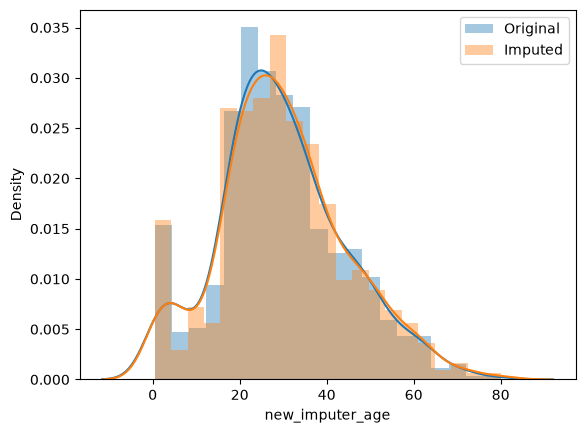

In [454]:
sns.distplot(X_train['Age'],label='Original',hist=True)
sns.distplot(X_train['new_imputer_age'],label = 'Imputed',hist=True)

plt.legend()
plt.show()

In [455]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['new_imputer_age'].var())

Original variable variance:  213.4440387522628
Variance after random imputation:  218.60066660955053


In [456]:
X_train[['Fare', 'Age', 'new_imputer_age']].cov()

,Fare,Age,new_imputer_age
Fare,2527.200071,70.362004,52.397209
Age,70.362004,213.444039,213.444039
new_imputer_age,52.397209,213.444039,218.600667


<Axes: >

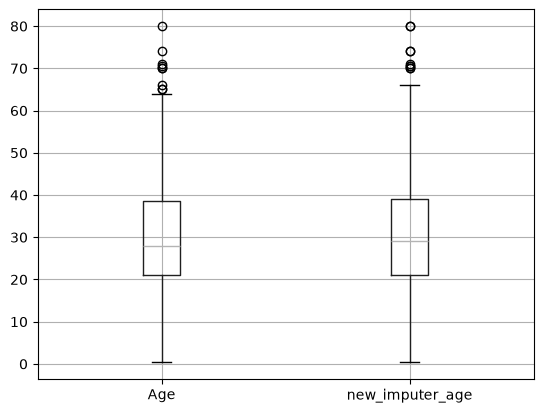

In [457]:
X_train[['Age', 'new_imputer_age']].boxplot()

In [458]:
data1 = pd.read_csv("Datasets\social_media_addiction_mental_wellbeing.csv")
data1.head()

,User_ID,Age,Gender,Occupation,Relationship_Status,Primary_Platform,Daily_Usage_Hours,Platforms_Used_Count,Posts_Per_Week,Late_Night_Usage,...,Loneliness_Score,Self_Esteem_Score,Sleep_Quality_Score,Sleep_Hours,Productivity_Loss_Score,Offline_Relationship_Quality,Physical_Activity_Hrs_Week,Screen_Free_Time_Hrs,Mental_Wellbeing_Score,Addiction_Level
0,USR00001,30,Male,Working Professional,In a Relationship,YouTube,2.9,4,3,No,...,1.7,6.5,8.5,5.3,3.7,3.8,5.8,3.1,7.3,Low
1,USR00002,19,Male,Student,Married,Instagram,4.8,1,0,NaN,...,7.0,7.5,7.8,5.5,4.0,1.8,0.9,3.3,4.1,Severe
2,USR00003,40,Male,Student,In a Relationship,YouTube,NaN,4,5,No,...,5.6,5.3,6.3,NaN,5.8,2.8,0.0,1.5,5.6,High
3,USR00004,37,Female,Student,Married,Facebook,7.7,2,3,Yes,...,5.6,1.4,3.9,6.1,5.5,3.6,1.0,3.9,4.3,Severe
4,USR00005,18,Non-binary,Student,In a Relationship,TikTok,4.6,3,0,No,...,4.0,NaN,5.7,5.0,3.8,3.2,0.6,1.0,6.6,Moderate


In [459]:
data1 = data1[['Gender','Primary_Platform','Mental_Wellbeing_Score']]
data1.head()

,Gender,Primary_Platform,Mental_Wellbeing_Score
0,Male,YouTube,7.3
1,Male,Instagram,4.1
2,Male,YouTube,5.6
3,Female,Facebook,4.3
4,Non-binary,TikTok,6.6


In [460]:
data1.isnull().mean()*100

Gender                    3.533333
Primary_Platform          3.533333
Mental_Wellbeing_Score    0.000000
dtype: float64

In [461]:
X_train,X_test,y_train,y_test = train_test_split(data1.drop(columns='Mental_Wellbeing_Score'),data1['Mental_Wellbeing_Score'],test_size=0.1,random_state=42)

In [462]:
X_train

,Gender,Primary_Platform
1358,Male,Instagram
1203,Female,YouTube
970,Female,Snapchat
1466,Male,Snapchat
526,Male,YouTube
...,...,...
1130,Female,Instagram
1294,Male,Instagram
860,Male,YouTube
1459,Male,NaN


In [463]:
X_train["New_Gender"] = X_train['Gender']
X_test["New_Gender"] = X_test['Gender']

X_train["New_Primary_Platform"] = X_train['Primary_Platform']
X_test["New_Primary_Platform"] = X_test['Primary_Platform']

In [464]:
X_train

,Gender,Primary_Platform,New_Gender,New_Primary_Platform
1358,Male,Instagram,Male,Instagram
1203,Female,YouTube,Female,YouTube
970,Female,Snapchat,Female,Snapchat
1466,Male,Snapchat,Male,Snapchat
526,Male,YouTube,Male,YouTube
...,...,...,...,...
1130,Female,Instagram,Female,Instagram
1294,Male,Instagram,Male,Instagram
860,Male,YouTube,Male,YouTube
1459,Male,NaN,Male,NaN


In [465]:
X_train['New_Gender'][X_train['New_Gender'].isnull()] = X_train['Gender'].dropna().sample(X_train['Gender'].isnull().sum()).values
X_test['New_Gender'][X_test['New_Gender'].isnull()] = X_train['Gender'].dropna().sample(X_test['Gender'].isnull().sum()).values

X_train['New_Primary_Platform'][X_train['New_Primary_Platform'].isnull()] = X_train['Primary_Platform'].dropna().sample(X_train['Primary_Platform'].isnull().sum()).values
X_test['New_Primary_Platform'][X_test['New_Primary_Platform'].isnull()] = X_train['Primary_Platform'].dropna().sample(X_test['Primary_Platform'].isnull().sum()).values

C:\Users\sunil\AppData\Local\Temp\ipykernel_10844\4054467142.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  X_train['New_Gender'][X_train['New_Gender'].isnull()] = X_train['Gender'].dropna().sample(X_train['Gender'].isnull().sum()).values
C:\Users\sunil\AppData\Local\Temp\ipykernel_10844\4054467142.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame o

In [466]:
X_train.isnull().sum()

Gender                  48
Primary_Platform        48
New_Gender              48
New_Primary_Platform    48
dtype: int64

In [467]:
data1 = pd.read_csv("Datasets\social_media_addiction_mental_wellbeing.csv")
data1.head()

,User_ID,Age,Gender,Occupation,Relationship_Status,Primary_Platform,Daily_Usage_Hours,Platforms_Used_Count,Posts_Per_Week,Late_Night_Usage,...,Loneliness_Score,Self_Esteem_Score,Sleep_Quality_Score,Sleep_Hours,Productivity_Loss_Score,Offline_Relationship_Quality,Physical_Activity_Hrs_Week,Screen_Free_Time_Hrs,Mental_Wellbeing_Score,Addiction_Level
0,USR00001,30,Male,Working Professional,In a Relationship,YouTube,2.9,4,3,No,...,1.7,6.5,8.5,5.3,3.7,3.8,5.8,3.1,7.3,Low
1,USR00002,19,Male,Student,Married,Instagram,4.8,1,0,NaN,...,7.0,7.5,7.8,5.5,4.0,1.8,0.9,3.3,4.1,Severe
2,USR00003,40,Male,Student,In a Relationship,YouTube,NaN,4,5,No,...,5.6,5.3,6.3,NaN,5.8,2.8,0.0,1.5,5.6,High
3,USR00004,37,Female,Student,Married,Facebook,7.7,2,3,Yes,...,5.6,1.4,3.9,6.1,5.5,3.6,1.0,3.9,4.3,Severe
4,USR00005,18,Non-binary,Student,In a Relationship,TikTok,4.6,3,0,No,...,4.0,NaN,5.7,5.0,3.8,3.2,0.6,1.0,6.6,Moderate


In [468]:
data = data1[['Age','Gender','Primary_Platform','Mental_Wellbeing_Score','Daily_Usage_Hours']]
data.head()

,Age,Gender,Primary_Platform,Mental_Wellbeing_Score,Daily_Usage_Hours
0,30,Male,YouTube,7.3,2.9
1,19,Male,Instagram,4.1,4.8
2,40,Male,YouTube,5.6,NaN
3,37,Female,Facebook,4.3,7.7
4,18,Non-binary,TikTok,6.6,4.6


In [469]:
x = data.drop(columns='Mental_Wellbeing_Score')
y = data['Mental_Wellbeing_Score']

In [470]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.1,random_state=42)

In [471]:
X_train.head()

,Age,Gender,Primary_Platform,Daily_Usage_Hours
1358,22,Male,Instagram,NaN
1203,39,Female,YouTube,6.4
970,31,Female,Snapchat,6.4
1466,23,Male,Snapchat,5.8
526,40,Male,YouTube,2.4


In [472]:
numerical_feature = ["Age","Daily_Usage_Hours"]
numerical_trasformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_features = ['Gender', 'Primary_Platform']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',OneHotEncoder(handle_unknown='ignore'))
])

In [473]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_trasformer, numerical_feature),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [474]:
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

In [475]:
from sklearn import set_config
set_config(display='diagram')
clf

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [476]:
param_grid = {
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    'preprocessor__cat__imputer__strategy': ['most_frequent', 'constant'],
    'classifier__C': [0.1, 1.0, 10, 100]
}

grid_search = GridSearchCV(clf, param_grid, cv=10)

In [477]:
X_train

,Age,Gender,Primary_Platform,Daily_Usage_Hours
1358,22,Male,Instagram,NaN
1203,39,Female,YouTube,6.4
970,31,Female,Snapchat,6.4
1466,23,Male,Snapchat,5.8
526,40,Male,YouTube,2.4
...,...,...,...,...
1130,28,Female,Instagram,2.1
1294,17,Male,Instagram,4.3
860,17,Male,YouTube,0.5
1459,18,Male,NaN,0.7


In [478]:
grid_search.fit(X_train, y_train)

print(f"Best params:")
print(grid_search.best_params_)

ValueError: 
All the 160 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
160 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\sunil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\sunil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\sunil\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\pipeline.py", line 649, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "c:\Users\sunil\AppData\Local\Pro